## Regional SAT anomalies calculation then calculate the trend

In [1]:
# In[1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# %%
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprocess

In [2]:
# import src.slurm_cluster as scluster
# client, scluster = scluster.init_dask_slurm_cluster(scale=2,cores=10, memory="200GB")

In [3]:
# load data
dir_HadCRUT5 = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG2/'
HadCRUT5 = xr.open_dataset(dir_HadCRUT5 + 'Raw_HadCRUT5_MK_trend_1950-2022_sliding.nc')

# dir_forced_unforced_anom = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS5_S6/cesm2_100/'
# HadCRUT5_partition_anom = xr.open_mfdataset(dir_forced_unforced_anom + 'OBS_SAT_anomaly_partition_wrt_MMLE_ENS.nc',chunks={'lat':10,'lon':10})
dir_forced_unforced = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS5_S6/cesm2_100'
HadCRUT5_forced = xr.open_mfdataset(dir_forced_unforced + '/trend_forced_HadCRUT5_annual/' + 'forced_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc',chunks={'lat':10,'lon':10}) 
HadCRUT5_internal = xr.open_mfdataset(dir_forced_unforced + '/trend_ICV_HadCRUT5_annual/' + 'ICV_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc',chunks={'lat':10,'lon':10})

In [4]:
HadCRUT5

<xarray.Dataset>
Dimensions:  (lat: 90, lon: 180, period: 64)
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
Data variables:
    trend    (period, lat, lon) float64 ...
    p_value  (period, lat, lon) float64 ...

### Calculate the trend end year fix to 2022, start with 73 year length and decrease length of trend every one year, the minimum trend length is 10yr 

In [5]:
temp_data = HadCRUT5.trend
temp_data_forced = HadCRUT5_forced.trend
temp_data_internal = HadCRUT5_internal.trend

In [6]:
#Perfrom land sea mask
land_sea_mask=xr.open_dataset('/work/mh0033/m301036/Data_storage/CMIP6-MPI-ESM-LR/GR15_lsm_regrid.nc')
# land_sea_mask.coords
land_sea_mask

# mask the land area trend data
mask_data = land_sea_mask['var1']
mask_data

<xarray.DataArray 'var1' (time: 1, lat: 90, lon: 180)>
[16200 values with dtype=float32]
Coordinates:
  * time     (time) float64 201.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
Attributes:
    code:     1

In [7]:
# Apply the land-sea mask to the trend data, mask the land area trend
temp_data_masked = temp_data.where(mask_data[0,:,:]==0, drop = False)
temp_data_forced_masked = temp_data_forced.where(mask_data[0,:,:]==0, drop = False)
temp_data_internal_masked = temp_data_internal.where(mask_data[0,:,:]==0, drop = False)

In [8]:
temp_data

<xarray.DataArray 'trend' (period: 64, lat: 90, lon: 180)>
[1036800 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'

In [9]:
# flip the longitude to -180 to 180
temp_data_adj = preprocess.convert_longitude(temp_data)
temp_data_forced_adj = preprocess.convert_longitude(temp_data_forced)
temp_data_internal_adj = preprocess.convert_longitude(temp_data_internal)

In [10]:
temp_data_masked_adj = preprocess.convert_longitude(temp_data_masked)
temp_data_forced_masked_adj = preprocess.convert_longitude(temp_data_forced_masked)
temp_data_internal_masked_adj = preprocess.convert_longitude(temp_data_internal_masked)

In [11]:
temp_data_adj

<xarray.DataArray 'trend' (period: 64, lat: 90, lon: 180)>
[1036800 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 -180.0 -178.0 -176.0 -174.0 ... 174.0 176.0 178.0
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'

In [12]:
type(temp_data_adj)

xarray.core.dataarray.DataArray

### Regional anomalies calculation

In [13]:
def plot_trend(temp_data, lats, lons, levels=None, extend=None, cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - temp_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """
    # Plotting
    contour_obj = ax.contourf(lons, lats, temp_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.35, linestyle='--')

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    # ax.set_title(title, loc='center', fontsize=18, pad=5.0)

    return contour_obj
# %%
plt.rcParams['figure.figsize'] = (8, 10)
plt.rcParams['font.size'] = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['savefig.transparent'] = True

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

In [14]:
levels = np.arange(-3.5, 4.0, 0.25)

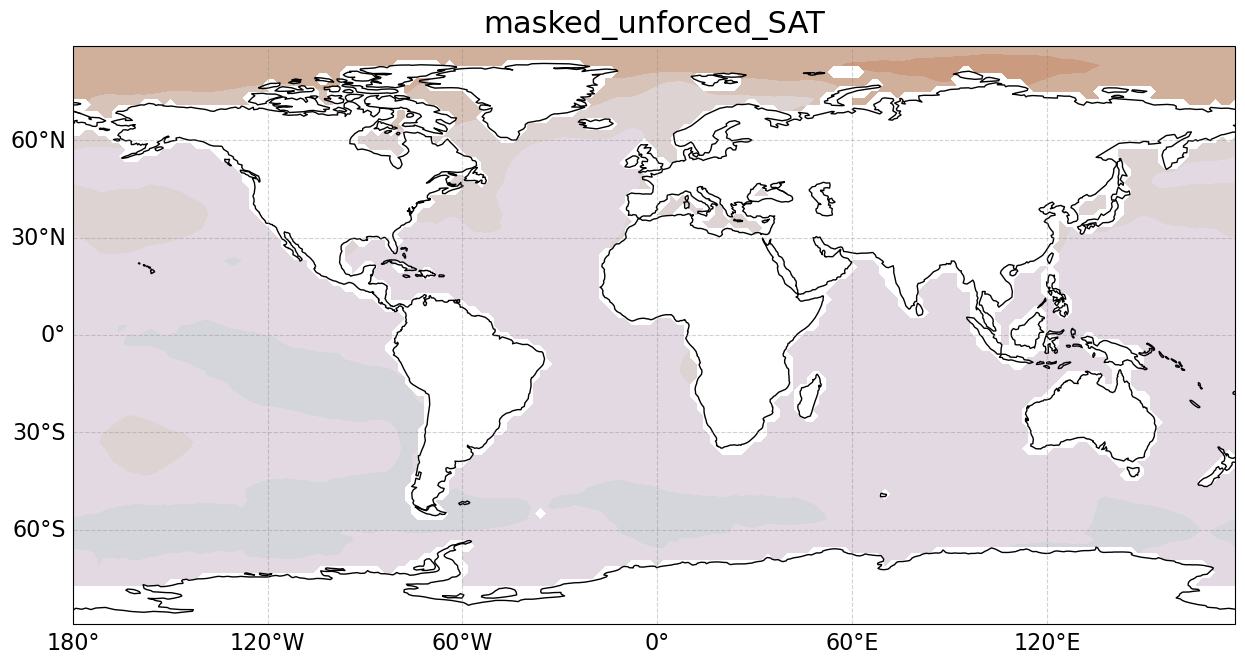

In [15]:
# Plot the North Atlantic region's temperature anomalies map
region_sel = temp_data_masked_adj.sel(period='1979-2022')
region_sel

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(1, 1, figure=fig, hspace=0.01, wspace=0.01)

ax = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree(central_longitude=0))
# ax.set_global()
# pvalue_annual_da_with_cyclic, _ = cutil.add_cyclic_point(pvalue_annual_da['40yr'], coord=lon)
contour_obj = plot_trend(region_sel, region_sel.lat, region_sel.lon, levels=levels,extend='both', cmap='twilight_shifted',
            title=" ", ax=ax, show_xticks=True, show_yticks=True)
ax.set_title('masked_unforced_SAT', fontsize=22, pad=10.0)

plt.show()

In [16]:
lat = temp_data_adj.lat
lon = temp_data_adj.lon

lat1 = 42
lat2 = 60
lon1 = -50
lon2 = -10

In [17]:
def calc_North_Atlantic_anomalies(data,mask_data):
    ds_WH = data.sel(lat=slice(42, 60), lon=slice(-50, -10))
    ds_WH_anomaly = data_process.calc_weighted_mean(ds_WH)
    ds_sel = mask_data.sel(lat=slice(0, 90), lon=slice(-180,180))
    ds_sel_anomaly = data_process.calc_weighted_mean(ds_sel)
    
    ds_anomalies = ds_WH_anomaly - ds_sel_anomaly
    return ds_anomalies

In [18]:
temp_data_adj_subpolar_gyre = calc_North_Atlantic_anomalies(temp_data_adj,temp_data_masked_adj)

temp_forced_data_adj_subpolar_gyre = calc_North_Atlantic_anomalies(temp_data_forced_adj,temp_data_forced_masked_adj)

temp_internal_data_adj_subpolar_gyre = calc_North_Atlantic_anomalies(temp_data_internal_adj,temp_data_internal_masked_adj)

In [22]:
temp_forced_data_adj_subpolar_gyre

<xarray.DataArray 'trend' (period: 64)>
dask.array<sub, shape=(64,), dtype=float64, chunksize=(64,), chunktype=numpy.ndarray>
Coordinates:
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
    time     float64 201.0

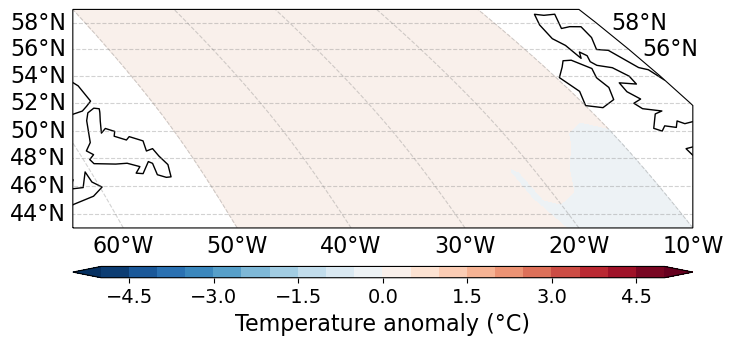

In [20]:
# plot the aractic region anomaly year 2020
# da_plot_subpolar_gyre = temp_internal_da_subpolar_gyre.sel(year=2020)
da_plot = temp_data_internal_adj.sel(period="1979-2022").sel(lat=slice(lat1, lat2), lon=slice(lon1, lon2))

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)})

contour_obj =  plot_trend(da_plot, da_plot.lat, da_plot.lon, levels=np.arange(-5, 5.5, 0.5), extend='both', cmap='RdBu_r',
                                    title="subpolar_gyre region SAT anomaly 2020", ax=ax, show_xticks=True, show_yticks=True)

# colorbar
cbar = plt.colorbar(contour_obj, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cbar.set_label('Temperature anomaly (°C)')
cbar.ax.tick_params(labelsize=14)

plt.show()


In [ ]:
dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG5/data/'

# temp_data_adj_subpolar_gyre.to_dataset(name='trend').to_netcdf(dir_out + 'Raw_subpolar_gyre_trend_1950-2022_sliding.nc')
# temp_forced_data_adj_subpolar_gyre.to_dataset(name='trend').to_netcdf(dir_out + 'Forced_subpolar_gyre_trend_1950-2022_sliding.nc')
# temp_internal_data_adj_subpolar_gyre.to_dataset(name='trend').to_netcdf(dir_out + 'Internal_subpolar_gyre_trend_1950-2022_sliding.nc')

### Segments definitions

In [24]:
# calculate the trend for each segment
trends = {}
for begin_year in temp_data_adj_subpolar_gyre.period.values:
    trends[begin_year] = {
        "raw": temp_data_adj_subpolar_gyre.sel(period=begin_year).values,
        "forced": temp_forced_data_adj_subpolar_gyre.sel(period=begin_year).values,
        "internal": temp_internal_data_adj_subpolar_gyre.sel(period=begin_year).values
    }

In [25]:
trends

{'1950-2022': {'raw': array(-0.08101425),
  'forced': array(-0.0891274),
  'internal': array(0.00075991)},
 '1951-2022': {'raw': array(-0.08287671),
  'forced': array(-0.09169993),
  'internal': array(0.00050685)},
 '1952-2022': {'raw': array(-0.08301296),
  'forced': array(-0.09415107),
  'internal': array(0.00229216)},
 '1953-2022': {'raw': array(-0.08016705),
  'forced': array(-0.09680763),
  'internal': array(0.00717451)},
 '1954-2022': {'raw': array(-0.07723437),
  'forced': array(-0.09943805),
  'internal': array(0.01176329)},
 '1955-2022': {'raw': array(-0.07386953),
  'forced': array(-0.10093785),
  'internal': array(0.0172335)},
 '1956-2022': {'raw': array(-0.06720503),
  'forced': array(-0.10188224),
  'internal': array(0.0262876)},
 '1957-2022': {'raw': array(-0.06117764),
  'forced': array(-0.10301008),
  'internal': array(0.03366553)},
 '1958-2022': {'raw': array(-0.05975704),
  'forced': array(-0.10422818),
  'internal': array(0.03759357)},
 '1959-2022': {'raw': array(-0.

In [26]:
trends_df = pd.DataFrame.from_dict(trends, orient='index')
trends_df

,raw,forced,internal
1950-2022,-0.08101425476180754,-0.0891274038341417,0.000759912792528546
1951-2022,-0.08287670840755572,-0.09169992584187485,0.0005068458375958318
1952-2022,-0.08301296103913432,-0.09415107267872647,0.002292163882544664
1953-2022,-0.08016704793606434,-0.09680763471952769,0.007174507406695045
1954-2022,-0.07723437382580496,-0.099438049649789,0.011763288130683103
...,...,...,...
2009-2022,-0.18828445923249879,-0.14131076893243982,-0.04759365170795514
2010-2022,-0.23940988730998794,-0.14242271628650208,-0.10036827867575981
2011-2022,-0.020300644992723604,-0.14133370388315764,0.11827785094232483
2012-2022,0.14363366475124928,-0.14074919862917926,0.280834118832943


In [27]:
# data frame to dataset
trends_ds = trends_df.to_xarray()

In [28]:
trends_ds

<xarray.Dataset>
Dimensions:   (index: 64)
Coordinates:
  * index     (index) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
Data variables:
    raw       (index) object -0.08101 -0.08288 -0.08301 ... 0.1436 0.5641
    forced    (index) object -0.08913 -0.0917 -0.09415 ... -0.1407 -0.1383
    internal  (index) object 0.0007599 0.0005068 0.002292 ... 0.2808 0.7027

In [29]:
# export the trend to the netcdf file
trends_ds.to_netcdf(dir_out + 'Subpolar_gyre_wrt_NAT_trend_variations.nc')

In [30]:
dirin = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG5/data/percentile/'
subpolar_gyre_unforced_lower = xr.open_dataset(f'{dirin}internal_subpolar_gyre_trend_lower_percentile.nc')
subpolar_gyre_unforced_upper = xr.open_dataset(f'{dirin}internal_subpolar_gyre_trend_upper_percentile.nc')

In [31]:
subpolar_gyre_unforced_lower

<xarray.Dataset>
Dimensions:               (ICV_trend_year_lower: 64)
Coordinates:
  * ICV_trend_year_lower  (ICV_trend_year_lower) object 'ICV_trend_10yr' ... ...
Data variables:
    ICV_trend_lower       (ICV_trend_year_lower) float64 ...

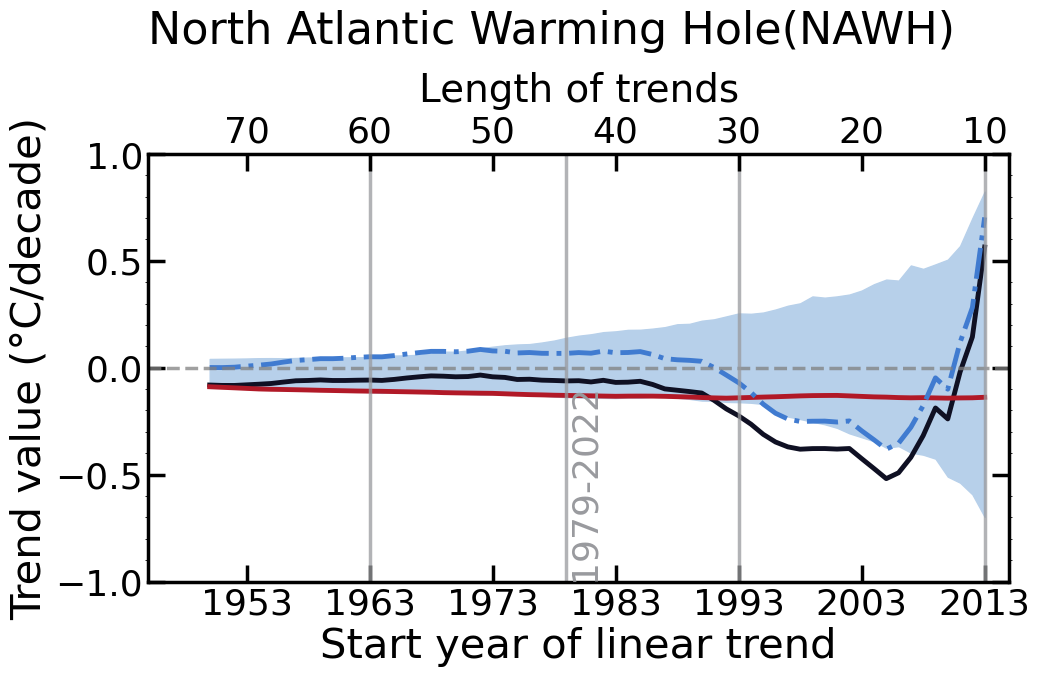

In [33]:
import seaborn as sns
from matplotlib.lines import Line2D

# sns.set_theme(style="whitegrid")
# Set the font dictionaries (for plot title and axis titles)
title_font = {'fontname': 'Arial', 'size': '20', 'color': 'black', 'weight': 'normal',
                'verticalalignment': 'bottom'}  # Bottom vertical alignment for more space
axis_font = {'fontname': 'Arial', 'size': '20'}

# Create the plot
fig = plt.figure(figsize=(25, 15))
gs = gridspec.GridSpec(2, 2, wspace=0.25, hspace=0.7)

ax1 = plt.subplot(gs[0, 0])
# ax2 = plt.subplot(gs[0, 1])
# ax3 = plt.subplot(gs[1, 0])
# ax4 = plt.subplot(gs[1, 1])

# define rgb colors for the outlines
# colors = [(32,120,180), #blue
#           (106,61,154), #purple
#           (173,23,88), #magenta
#           (255,127,0), #orange
#           (226,26,27),#red
#           (49,160,45) #green
#          ]
# colors_set = [(r / 255, g / 255, b / 255) for r, g, b in colors]
colors = ['#0F1023','#B11927', '#407BD0', '#B7D0EA']
line_widths = [5.5, 5.5, 5.5, 5.5, 1.5, 1.5, 1.5]
titles = ['North Atlantic Warming Hole(NAWH)']
linestyles = ['-', '-', '-.', ':']
years = np.arange(1950, 2014)

vars = ['raw', 'forced', 'internal']
# We use a loop to simulate multiple lines for each category
for i, var in enumerate(vars):
    y_vals = trends_ds[var].astype(float).values
    sns.lineplot(x=years, y=y_vals, color=colors[i], linestyle=linestyles[i], linewidth=3.5, ax=ax1)
    
ax1.fill_between(np.arange(1950,2014), subpolar_gyre_unforced_lower.ICV_trend_lower.values[::-1], subpolar_gyre_unforced_upper.ICV_trend_upper.values[::-1], color=colors[3])

ax1.set_xlim([1945, 2015])
ax1.set_ylim([-1.0, 1.0])
ax1.set_xticks([1953, 1963, 1973, 1983, 1993, 2003, 2013])
ax1.set_xticklabels(['1953', '1963', '1973', '1983', '1993', '2003', '2013'])
ax1_upper = ax1.twiny()
ax1_upper.invert_xaxis()
ax1_upper.set_xlim([78,8])
ax1_upper.set_xlabel('Length of trends', fontsize=28, labelpad=10)
ax1_upper.set_xticks([70, 60, 50, 40, 30, 20, 10])
ax1_upper.set_xticklabels(['70', '60', '50', '40', '30', '20', '10'])
ax1.spines['top'].set_linewidth(2.5)
ax1.spines['right'].set_linewidth(2.5)
ax1.spines['bottom'].set_linewidth(2.5)
ax1.spines['left'].set_linewidth(2.5)
ax1_upper.tick_params(axis='x', labelsize=26)
ax1_upper.tick_params(axis='x', which='major', length=12, width=2.5, direction='in')
ax1.axhline(y=0, color='grey', linestyle='--', linewidth=2.5, alpha=0.75)
ax1.set_ylabel('Trend value (°C/decade)', fontsize=30)
ax1.set_xlabel('Start year of linear trend', fontsize=30)
ax1.set_title(titles[0], loc='left',fontsize=32,pad=20)
ax1.tick_params(axis='x', which='major', length=12, labelsize=26, width=2.5, direction='in')
ax1.tick_params(axis='y', which='major', length=12, labelsize=26, width=2.5, direction='in')
ax1.axvline(x=2013, color='#999A9E', linestyle='-', linewidth=2.5, alpha=0.75)
ax1.axvline(x=1993, color='#999A9E', linestyle='-', linewidth=2.5, alpha=0.75)
ax1.axvline(x=1979, color='#999A9E', linestyle='-', linewidth=2.5, alpha=0.75)
ax1.axvline(x=1963, color='#999A9E', linestyle='-', linewidth=2.5, alpha=0.75)
ax1.text(1979.1, -0.96, '1979-2022', fontsize=26, rotation=90, color='#999A9E')
# ax1.text(1940, 1.58, 'c', fontsize=42, ha='center', va='center', fontweight='bold')
# custom_lines = [Line2D([0], [0], color=colors[0], lw=3.5),
#                 Line2D([0], [0], color=colors[1], lw=3.5),
#                 Line2D([0], [0], color=colors[2], lw=3.5)]
# leg2 = ax1.legend(custom_lines, ['total', 'human forced', 'internal variability'], 
#                   loc='lower left', fontsize=26)
# ax1.add_artist(leg2)
plt.savefig('./NAWH_trend_variations.png', dpi=300, bbox_inches='tight')
plt.show()